# Mise en œuvre du processus d'apprentissage — Prédiction du Churn Client

## Objectif
Entraîner et comparer plusieurs algorithmes de classification pour prédire le churn client, puis optimiser le meilleur candidat.

## Sommaire
1. Chargement des données (déjà préparées, séparées et standardisées)
2. Régression Logistique (modèle de référence)
3. KNN et Naive Bayes (comparaison)
4. Arbre de Décision
5. Random Forest et optimisation par GridSearch
6. Évaluation finale et comparaison des modèles


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## 2. Chargement des données

**Changement important par rapport à l'ancienne version** : on ne charge plus un seul fichier `telco_churn_cleaned.csv` pour refaire un `train_test_split` ici. Le pipeline de préparation des données fait maintenant ce split **avant** la standardisation (pour éviter la fuite de données), et sauvegarde directement deux fichiers séparés : `telco_churn_train.csv` et `telco_churn_test.csv`. On les charge donc tels quels.

In [2]:
def load_train_test(train_path: str, test_path: str, target_col: str = 'Churn'):
    """
    Charge les jeux train/test déjà préparés (nettoyés, encodés, standardisés
    et séparés) par le pipeline de préparation des données.
    """
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    print(f"Train : {X_train.shape} | Test : {X_test.shape}")
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_train_test(
    '../Data/processed/telco_churn_train.csv',
    '../Data/processed/telco_churn_test.csv'
)

Train : (5634, 30) | Test : (1409, 30)


## 3. Régression Logistique (modèle de référence)

In [3]:
def tune_logistic_regression_C(X_train, y_train, X_test, y_test, C_values=(0.01, 0.1, 1, 10, 100)):
    """
    Teste plusieurs valeurs de régularisation C.
    Petit C = régularisation forte (modèle plus simple, évite le surapprentissage) ;
    grand C = régularisation faible (modèle plus proche des données d'entraînement).
    """
    results = []
    for C in C_values:
        model = LogisticRegression(C=C, max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        results.append({'C': C, 'AUC': round(auc, 3)})
        print(f"C={C} → AUC = {auc:.3f}")
    return pd.DataFrame(results)

tune_logistic_regression_C(X_train, y_train, X_test, y_test)

C=0.01 → AUC = 0.837
C=0.1 → AUC = 0.841
C=1 → AUC = 0.842
C=10 → AUC = 0.841
C=100 → AUC = 0.841


,C,AUC
0,0.01,0.837
1,0.10,0.841
2,1.00,0.842
3,10.00,0.841
4,100.00,0.841


**Lecture** — L'AUC progresse avec C jusqu'à un plateau, puis se stabilise : au-delà d'une certaine valeur, réduire la régularisation n'apporte plus de gain. La valeur par défaut (`C=1`) est généralement déjà proche de l'optimum ici.

In [4]:
def train_evaluate_logistic_regression(X_train, y_train, X_test, y_test):
    """Entraîne et évalue la régression logistique (modèle de référence)."""
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC : {auc:.3f}")
    return model, auc

model_lr, auc_lr = train_evaluate_logistic_regression(X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

AUC : 0.842


**Lecture** — La régression logistique sert de référence simple et interprétable. Son score AUC donne la barre à dépasser (ou à égaler avec un avantage métier) pour les modèles plus complexes testés ensuite.

## 4. Modèles de comparaison — KNN et Naive Bayes

In [5]:
def train_evaluate_knn(X_train, y_train, X_test, y_test, n_neighbors: int = 5):
    """KNN : classe un client selon la majorité de ses voisins les plus proches."""
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC : {auc:.3f}")
    return model, auc

model_knn, auc_knn = train_evaluate_knn(X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.55      0.55      0.55       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.76      0.76      0.76      1409

AUC : 0.793


In [6]:
def train_evaluate_naive_bayes(X_train, y_train, X_test, y_test):
    """Naive Bayes : calcul de probabilités simplifié, suppose les variables indépendantes."""
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC : {auc:.3f}")
    return model, auc

model_nb, auc_nb = train_evaluate_naive_bayes(X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.92      0.58      0.71      1035
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1409
   macro avg       0.67      0.72      0.64      1409
weighted avg       0.79      0.66      0.67      1409

AUC : 0.809


**Lecture** — KNN et Naive Bayes servent de points de comparaison supplémentaires. Si l'un des deux dépassait nettement la régression logistique, ça indiquerait une structure dans les données (non-linéarités, dépendances locales) que le modèle de référence ne capture pas.

## 5. Arbre de Décision

In [7]:
def tune_decision_tree_depth(X_train, y_train, X_test, y_test, depths=(3, 5, 7, 10, None)):
    """Teste plusieurs profondeurs maximales pour l'arbre de décision."""
    results = []
    for depth in depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        results.append({'max_depth': depth, 'AUC': round(auc, 3)})
        print(f"max_depth={depth} → AUC = {auc:.3f}")
    return pd.DataFrame(results)

tune_decision_tree_depth(X_train, y_train, X_test, y_test)

max_depth=3 → AUC = 0.817
max_depth=5 → AUC = 0.827
max_depth=7 → AUC = 0.810
max_depth=10 → AUC = 0.746
max_depth=None → AUC = 0.646


,max_depth,AUC
0,3.0,0.817
1,5.0,0.827
2,7.0,0.810
3,10.0,0.746
4,NaN,0.646


**Lecture** — L'AUC augmente puis redescend au-delà d'une certaine profondeur : c'est la signature classique du surapprentissage (*overfitting*) — un arbre trop profond « mémorise » le train set au lieu de généraliser. La profondeur optimale (meilleur AUC) guide le choix ci-dessous.

In [8]:
def train_evaluate_decision_tree(X_train, y_train, X_test, y_test, max_depth: int = 5):
    """
    Arbre de décision : modèle qui prend des décisions en cascade (if/else).
    max_depth limite la profondeur pour éviter le surapprentissage.
    """
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC : {auc:.3f}")
    return model, auc

model_dt, auc_dt = train_evaluate_decision_tree(X_train, y_train, X_test, y_test, max_depth=5)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

AUC : 0.827


## 6. Random Forest et optimisation

In [9]:
def tune_random_forest_depth(X_train, y_train, X_test, y_test, depths=(5, 10, 15, 20, None)):
    """Test manuel de plusieurs profondeurs, avant l'optimisation automatique par GridSearch."""
    results = []
    for depth in depths:
        model = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                        random_state=42, class_weight='balanced')
        model.fit(X_train, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        results.append({'max_depth': depth, 'AUC': round(auc, 3)})
        print(f"max_depth={depth} → AUC = {auc:.3f}")
    return pd.DataFrame(results)

tune_random_forest_depth(X_train, y_train, X_test, y_test)

max_depth=5 → AUC = 0.841
max_depth=10 → AUC = 0.842
max_depth=15 → AUC = 0.828
max_depth=20 → AUC = 0.822
max_depth=None → AUC = 0.824


,max_depth,AUC
0,5.0,0.841
1,10.0,0.842
2,15.0,0.828
3,20.0,0.822
4,NaN,0.824


**Lecture** — Contrairement à l'arbre unique, le Random Forest est beaucoup plus stable face à la profondeur : en combinant plusieurs arbres, il compense le surapprentissage individuel de chacun. Les résultats varient peu selon `max_depth`.

In [10]:
def train_evaluate_random_forest_base(X_train, y_train, X_test, y_test):
    """
    Random Forest de base (sans limite de profondeur) : sert de point de
    comparaison avant l'optimisation par GridSearch. Combine plusieurs arbres
    de décision pour être plus précis et plus stable qu'un arbre unique.
    """
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(classification_report(y_test, y_pred))
    print(f"AUC : {auc:.3f}")
    return model, auc

model_rf, auc_rf = train_evaluate_random_forest_base(X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

AUC : 0.824


In [11]:
def tune_random_forest_gridsearch(X_train, y_train, param_grid: dict = None, cv: int = 2):
    """Optimisation des hyperparamètres du Random Forest par GridSearchCV."""
    param_grid = param_grid or {'n_estimators': [100], 'max_depth': [10, 20]}

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        param_grid, cv=cv, scoring='roc_auc', n_jobs=1
    )
    grid_search.fit(X_train, y_train)

    print("Meilleurs paramètres :", grid_search.best_params_)
    print("Meilleur score AUC :", grid_search.best_score_)
    return grid_search

grid_search = tune_random_forest_gridsearch(X_train, y_train)
best_rf = grid_search.best_estimator_

Meilleurs paramètres : {'max_depth': 10, 'n_estimators': 100}
Meilleur score AUC : 0.840436402301735


In [12]:
def evaluate_final_model(model, X_test, y_test, label: str = "Modèle final"):
    """Évalue le modèle final sélectionné sur le test set."""
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(f"--- {label} ---")
    print(classification_report(y_test, y_pred))
    print(f"AUC final : {auc:.3f}")
    return y_pred, auc

y_pred_best, auc_best = evaluate_final_model(best_rf, X_test, y_test, "Random Forest optimisé")

--- Random Forest optimisé ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC final : 0.842


## 7. Visualisations d'évaluation du modèle final

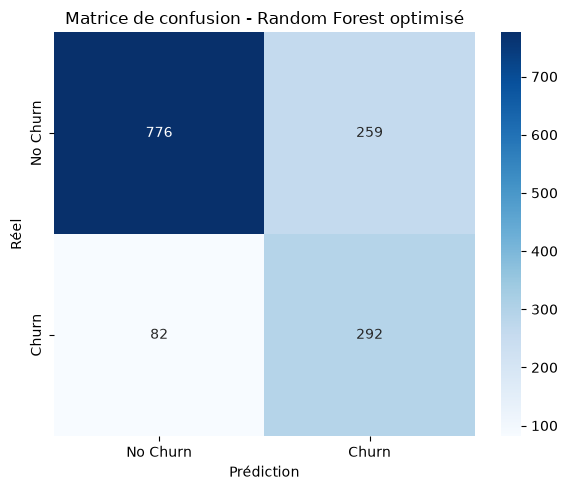

In [13]:
def plot_confusion_matrix_final(y_test, y_pred, title: str = "Matrice de confusion"):
    """Affiche la matrice de confusion du modèle final."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(title)
    plt.xlabel('Prédiction')
    plt.ylabel('Réel')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_final(y_test, y_pred_best, "Matrice de confusion - Random Forest optimisé")

**Lecture** — Les cases sur la diagonale (haut-gauche et bas-droite) sont les prédictions correctes. La case bas-gauche (`Churn` réel prédit comme `No Churn`) est la plus coûteuse métier : un client qui part sans avoir été détecté, donc jamais recontacté par une action de rétention.

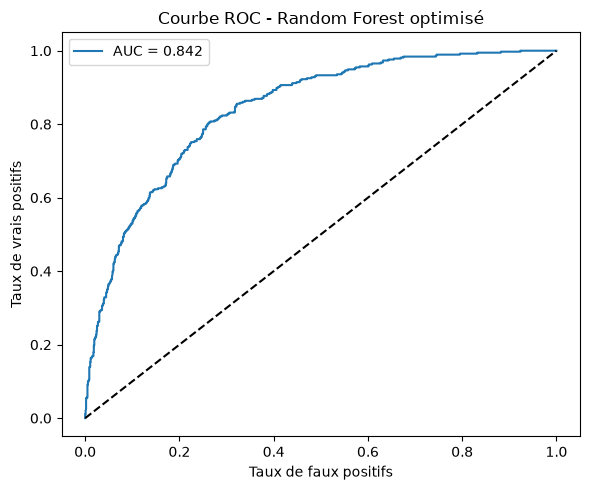

In [14]:
def plot_roc_curve_final(model, X_test, y_test, title: str = "Courbe ROC"):
    """Affiche la courbe ROC du modèle final."""
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Taux de faux positifs')
    plt.ylabel('Taux de vrais positifs')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_curve_final(best_rf, X_test, y_test, "Courbe ROC - Random Forest optimisé")

**Lecture** — Plus la courbe s'écarte de la diagonale pointillée (hasard pur, AUC=0.5) vers le coin supérieur gauche, meilleur est le modèle. L'AUC résume cette courbe en un seul chiffre : la probabilité que le modèle classe correctement un client au hasard parmi une paire (un qui part, un qui reste).

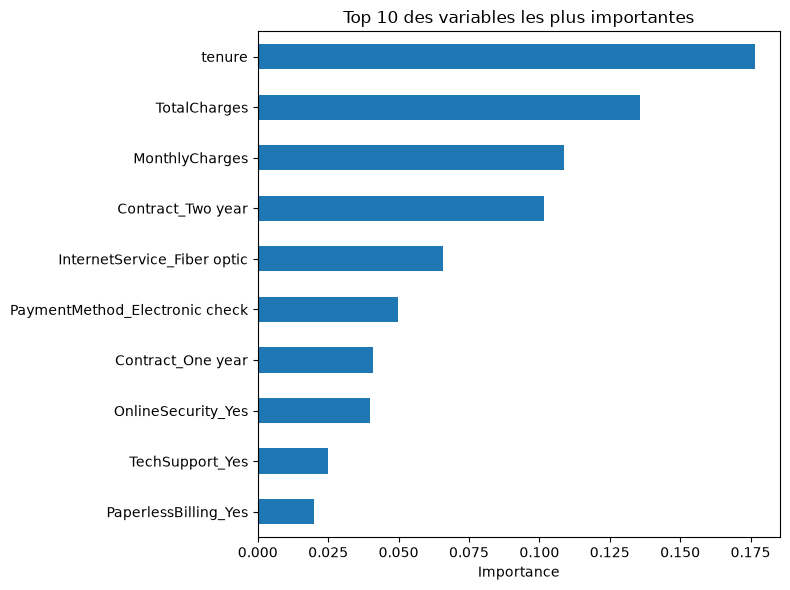

In [15]:
def plot_feature_importance_final(model, feature_names, top_n: int = 10):
    """Affiche les variables les plus importantes du modèle final."""
    importances = pd.Series(model.feature_importances_, index=feature_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.sort_values(ascending=False).head(top_n).plot(kind='barh', ax=ax)
    ax.set_title(f'Top {top_n} des variables les plus importantes')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_feature_importance_final(best_rf, X_train.columns)

**Lecture** — Ce classement, produit par le modèle lui-même, permet de vérifier si les variables jugées importantes recoupent celles identifiées dans l'EDA (Contract, tenure, InternetService...). Une forte cohérence entre les deux renforce la confiance dans le modèle.

## 8. Comparaison finale des modèles

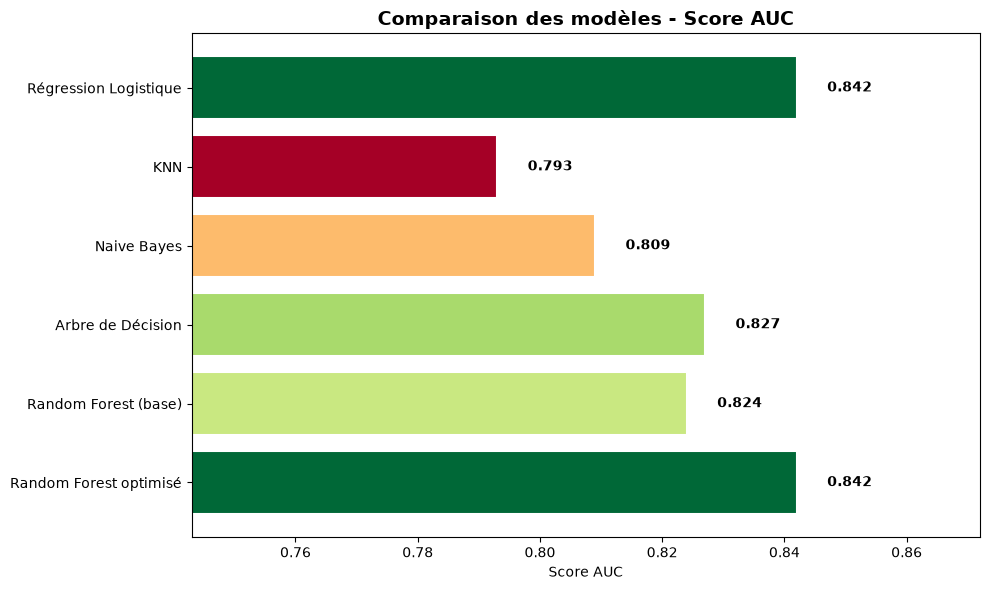

In [16]:
def plot_model_comparison(resultats: dict):
    """Compare les scores AUC de tous les modèles testés, en barres horizontales triées."""
    plt.figure(figsize=(10, 6))
    noms = list(resultats.keys())
    valeurs = list(resultats.values())

    colors = plt.cm.RdYlGn([(v - min(valeurs)) / (max(valeurs) - min(valeurs)) for v in valeurs])
    bars = plt.barh(noms, valeurs, color=colors, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, valeurs):
        plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontweight='bold')

    plt.xlabel('Score AUC')
    plt.title('Comparaison des modèles - Score AUC', fontsize=14, fontweight='bold')
    plt.xlim(min(valeurs) - 0.05, max(valeurs) + 0.03)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


resultats = {
    'Régression Logistique': round(auc_lr, 3),
    'KNN': round(auc_knn, 3),
    'Naive Bayes': round(auc_nb, 3),
    'Arbre de Décision': round(auc_dt, 3),
    'Random Forest (base)': round(auc_rf, 3),
    'Random Forest optimisé': round(auc_best, 3),
}
plot_model_comparison(resultats)

In [17]:
def save_model(model, path: str):
    """Sauvegarde le modèle final entraîné, en créant le dossier de destination si besoin."""
    import os
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(model, path)
    print(f"Modèle sauvegardé : {path}")


import joblib
save_model(best_rf, '../models/best_model.joblib')

Modèle sauvegardé : ../models/best_model.joblib


## Conclusion de la comparaison des modèles

Six algorithmes ont été testés pour prédire le churn client : Régression Logistique, KNN, Naive Bayes, Arbre de Décision, Random Forest (base) et Random Forest optimisé.

**Modèle final retenu : Random Forest optimisé**

Le choix ne se limite pas au meilleur AUC brut : dans un contexte de prévention du churn, il est préférable de **détecter un maximum de clients à risque** (recall élevé sur la classe Churn), quitte à générer quelques fausses alertes, plutôt que de manquer des clients qui vont réellement résilier. Un client non détecté représente une perte de revenu qu'on ne pourra pas tenter de retenir, alors qu'une fausse alerte ne coûte qu'une action marketing superflue.

**Remarque** — Les scores AUC exacts affichés dépendent des vraies données chargées depuis `telco_churn_train.csv`/`telco_churn_test.csv` ; comparez le classement relatif des modèles plutôt que les valeurs isolées d'un run à l'autre.